In [ ]:
c


In [1258]:
# add data set
space_df = pd.read_csv("data/Master_Space_Data_All.txt")
space_df.head()

,Company Name,Location,Datum,Detail,Status Rocket,Price,Status Mission
0,SpaceX,"SLC-4E, Vandenberg SFB, CA",Feb 25 2026 14:12 UTC,Falcon 9 Block 5 | Starlink Group 17-26,StatusActive,52.0,Success
1,SpaceX,"SLC-40, Cape Canaveral SFS, FL",Feb 24 2026 23:04 UTC,Falcon 9 Block 5 | Starlink Group 6-110,StatusActive,52.0,Success
2,SpaceX,"SLC-4E, Vandenberg SFB, CA",Feb 21 2026 13:42 UTC,Falcon 9 Block 5 | Starlink Group 11-5,StatusActive,52.0,Success
3,CASC,"Xichang Satellite Launch Center, China",Feb 21 2026 09:30 UTC,Long March 2C | Geely-03 Group 01,StatusActive,30.0,Success
4,SpaceX,"SLC-40, Cape Canaveral SFS, FL",Feb 19 2026 10:48 UTC,Falcon 9 Block 5 | Starlink Group 6-109,StatusActive,52.0,Success


In [1259]:
# convert into numeric, removing commas and coercing errors to NaN
space_df['Price'] = pd.to_numeric(space_df['Price'].astype(str).str.replace(',', ''), errors='coerce')

In [1260]:
space_df.head()

,Company Name,Location,Datum,Detail,Status Rocket,Price,Status Mission
0,SpaceX,"SLC-4E, Vandenberg SFB, CA",Feb 25 2026 14:12 UTC,Falcon 9 Block 5 | Starlink Group 17-26,StatusActive,52.0,Success
1,SpaceX,"SLC-40, Cape Canaveral SFS, FL",Feb 24 2026 23:04 UTC,Falcon 9 Block 5 | Starlink Group 6-110,StatusActive,52.0,Success
2,SpaceX,"SLC-4E, Vandenberg SFB, CA",Feb 21 2026 13:42 UTC,Falcon 9 Block 5 | Starlink Group 11-5,StatusActive,52.0,Success
3,CASC,"Xichang Satellite Launch Center, China",Feb 21 2026 09:30 UTC,Long March 2C | Geely-03 Group 01,StatusActive,30.0,Success
4,SpaceX,"SLC-40, Cape Canaveral SFS, FL",Feb 19 2026 10:48 UTC,Falcon 9 Block 5 | Starlink Group 6-109,StatusActive,52.0,Success


In [1261]:
space_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5319 entries, 0 to 5318
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Company Name    5319 non-null   object 
 1   Location        5319 non-null   object 
 2   Datum           5319 non-null   object 
 3   Detail          5318 non-null   object 
 4   Status Rocket   5316 non-null   object 
 5   Price           5315 non-null   float64
 6   Status Mission  5315 non-null   object 
dtypes: float64(1), object(6)
memory usage: 291.0+ KB


In [1262]:
# fill NaN values with 0 and convert to float
space_df['Price'] = space_df['Price'].fillna(0).astype(float)

In [1263]:
print(space_df.columns)

Index(['Company Name', 'Location', 'Datum', 'Detail', 'Status Rocket', 'Price',
       'Status Mission'],
      dtype='object')


In [1264]:
# extract country from Location column
space_df['countries'] = space_df['Location'].str.split(',').str[-1].str.strip()

In [1265]:
# take states out of USA
usa_states = ['CA', 'FL', 'TX', 'Texas', 'New Mexico', 'Virginia']
space_df['countries'] = space_df['countries'].replace(usa_states, 'USA')

In [1266]:
print(space_df[['Location', 'countries']].head())

                                 Location countries
0              SLC-4E, Vandenberg SFB, CA       USA
1          SLC-40, Cape Canaveral SFS, FL       USA
2              SLC-4E, Vandenberg SFB, CA       USA
3  Xichang Satellite Launch Center, China     China
4          SLC-40, Cape Canaveral SFS, FL       USA


In [1267]:
space_df.sample()

,Company Name,Location,Datum,Detail,Status Rocket,Price,Status Mission,countries
3478,General Dynamics,"SLC-36A, Cape Canaveral AFS, Florida, USA","Fri Jan 18, 1980 01:26 UTC",Atlas-SLV3D Centaur-D1AR | FLTSATCOM-3,StatusRetired,0.0,Success,USA


In [1268]:
space_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5319 entries, 0 to 5318
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Company Name    5319 non-null   object 
 1   Location        5319 non-null   object 
 2   Datum           5319 non-null   object 
 3   Detail          5318 non-null   object 
 4   Status Rocket   5316 non-null   object 
 5   Price           5319 non-null   float64
 6   Status Mission  5315 non-null   object 
 7   countries       5319 non-null   object 
dtypes: float64(1), object(7)
memory usage: 332.6+ KB


In [1269]:
# space_df['Date'] = pd.to_datetime(space_df['Datum'], errors='coerce', utc=True).dt.year

In [1270]:
# extract year from Datum column using regex
def extract_year(text):
    if pd.isna(text):
        return None
    match = re.search(r'(19\d{2}|20\d{2})', str(text))
    return int(match.group(1)) if match else None

space_df['date'] = space_df['Datum'].apply(extract_year)

In [1271]:
space_df.sample()

,Company Name,Location,Datum,Detail,Status Rocket,Price,Status Mission,countries,date
1923,Arianespace,"ELA-3, Guiana Space Centre, French Guiana, France","Sat Mar 11, 2006 22:33 UTC",Ariane 5 ECA | Spainsat & Hot Bird 7A,StatusActive,200.0,Success,France,2006.0


In [1272]:
space_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5319 entries, 0 to 5318
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Company Name    5319 non-null   object 
 1   Location        5319 non-null   object 
 2   Datum           5319 non-null   object 
 3   Detail          5318 non-null   object 
 4   Status Rocket   5316 non-null   object 
 5   Price           5319 non-null   float64
 6   Status Mission  5315 non-null   object 
 7   countries       5319 non-null   object 
 8   date            5134 non-null   float64
dtypes: float64(2), object(7)
memory usage: 374.1+ KB


In [1273]:
# convert date to Int64 
space_df['date'] = space_df['date'].astype('Int64')

In [1274]:
space_df.head()

,Company Name,Location,Datum,Detail,Status Rocket,Price,Status Mission,countries,date
0,SpaceX,"SLC-4E, Vandenberg SFB, CA",Feb 25 2026 14:12 UTC,Falcon 9 Block 5 | Starlink Group 17-26,StatusActive,52.0,Success,USA,2026
1,SpaceX,"SLC-40, Cape Canaveral SFS, FL",Feb 24 2026 23:04 UTC,Falcon 9 Block 5 | Starlink Group 6-110,StatusActive,52.0,Success,USA,2026
2,SpaceX,"SLC-4E, Vandenberg SFB, CA",Feb 21 2026 13:42 UTC,Falcon 9 Block 5 | Starlink Group 11-5,StatusActive,52.0,Success,USA,2026
3,CASC,"Xichang Satellite Launch Center, China",Feb 21 2026 09:30 UTC,Long March 2C | Geely-03 Group 01,StatusActive,30.0,Success,China,2026
4,SpaceX,"SLC-40, Cape Canaveral SFS, FL",Feb 19 2026 10:48 UTC,Falcon 9 Block 5 | Starlink Group 6-109,StatusActive,52.0,Success,USA,2026


In [1275]:
#adding lat and lon columns

location_coords = {
    "Plesetsk Cosmodrome": [64.6970, 40.2320],
    "Cape Canaveral": [28.4962, -80.5772],
    "Baikonur Cosmodrome": [45.9697, 63.3042],
    "Vandenberg SFB": [34.6370, -120.6146],
    "Vandenberg AFB": [34.6370, -120.6146],
    "Vandenberg": [34.6370, -120.6146],
    "French Guiana": [5.2380, -52.7762],
    "Kennedy Space Center": [28.5746, -80.6520],
    "Jiuquan": [40.9861, 100.2083],
    "Xichang": [27.9006, 102.2435],
    "Kapustin Yar": [48.6437, 45.7721],
    "Taiyuan": [38.8487, 111.6080],
    "Tanegashima": [30.4018, 130.9774],
    "Sriharikota": [13.7406, 80.2340],
    "Uchinoura": [31.2515, 131.0762],
    "Wallops Flight Facility": [37.9342, -75.4724],
    "Mahia Peninsula": [-39.2380, 177.8746],
    "Mahia, New Zealand": [-39.2380, 177.8746],
    "Wenchang": [19.5768, 110.7480],
    "Corn Ranch": [31.4230, -104.7571],
    "Vostochny Cosmodrome": [51.8495, 128.3552],
    "Semnan": [35.9543, 53.8075],
    "Yellow Sea": [36.7039, 121.2359],
    "Palmachim": [31.9064, 34.6933],
    "Kwajalein Atoll": [8.9836, 167.5780],
    "Kodiak Launch Complex": [57.4309, -152.3563],
    "Starbase": [25.9923, -97.1848],
    "San Marco Platform": [-2.9955, 40.1948],
    "Woomera": [-31.0688, 136.4426],
    "Point Mugu": [34.0870, -119.0610],
    "Edwards AFB": [34.9175, -117.8912],
    "Naro Space Center": [34.4536, 127.5179],
    "Spaceport America": [32.9903, -106.9750],
    "Hammaguir": [30.8678, -3.0436],
    "Mojave Air and Space Port": [35.0293, -118.1059],
    "Sohae": [39.6683, 124.7070],
    "Gran Canaria": [27.9252, -15.6214],
    "S. Korea": [36.6432, 127.2068]
}

# 2. Define a function to find the match
def get_lat_lon(loc_string):
    for key, coords in location_coords.items():
        if key.lower() in str(loc_string).lower():
            return pd.Series(coords)
    return pd.Series([None, None])

# 3. Apply the function to create 'Lat' and 'Lon' columns
# Assuming your dataframe is named 'space_df' and has a column 'Location'
space_df[['Lat', 'Lon']] = space_df['Location'].apply(get_lat_lon)



In [1276]:
space_df.head()

,Company Name,Location,Datum,Detail,Status Rocket,Price,Status Mission,countries,date,Lat,Lon
0,SpaceX,"SLC-4E, Vandenberg SFB, CA",Feb 25 2026 14:12 UTC,Falcon 9 Block 5 | Starlink Group 17-26,StatusActive,52.0,Success,USA,2026,34.6370,-120.6146
1,SpaceX,"SLC-40, Cape Canaveral SFS, FL",Feb 24 2026 23:04 UTC,Falcon 9 Block 5 | Starlink Group 6-110,StatusActive,52.0,Success,USA,2026,28.4962,-80.5772
2,SpaceX,"SLC-4E, Vandenberg SFB, CA",Feb 21 2026 13:42 UTC,Falcon 9 Block 5 | Starlink Group 11-5,StatusActive,52.0,Success,USA,2026,34.6370,-120.6146
3,CASC,"Xichang Satellite Launch Center, China",Feb 21 2026 09:30 UTC,Long March 2C | Geely-03 Group 01,StatusActive,30.0,Success,China,2026,27.9006,102.2435
4,SpaceX,"SLC-40, Cape Canaveral SFS, FL",Feb 19 2026 10:48 UTC,Falcon 9 Block 5 | Starlink Group 6-109,StatusActive,52.0,Success,USA,2026,28.4962,-80.5772


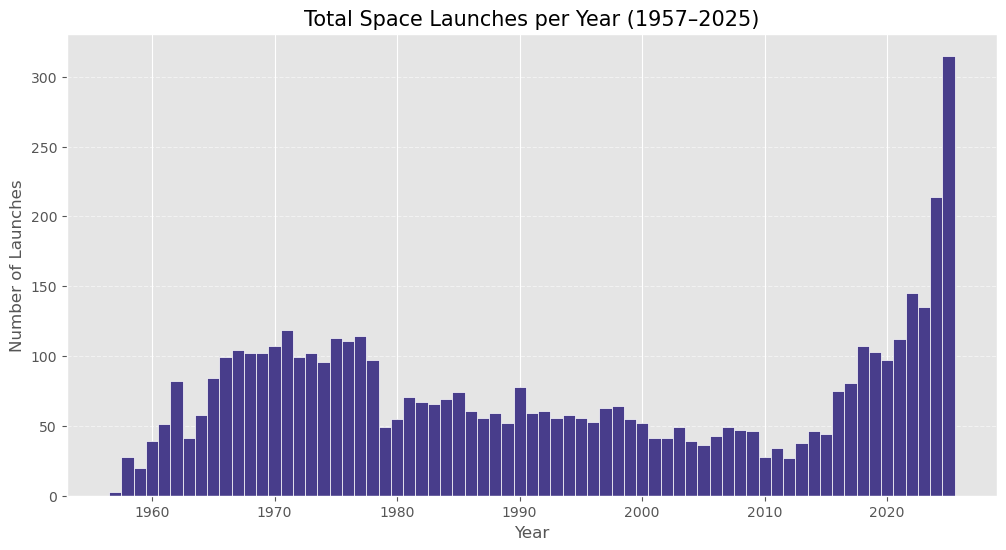

In [1277]:
df_filtered = space_df[space_df['date'] <= 2025]

# 3. Plot the distribution
plt.figure(figsize=(12, 6))
min_yr, max_yr = int(df_filtered['date'].min()), int(df_filtered['date'].max())

plt.hist(df_filtered['date'], bins=range(min_yr, max_yr + 2), 
         color='darkslateblue', edgecolor='white', align='left')

plt.title('Total Space Launches per Year (1957–2025)', fontsize=15)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Launches', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

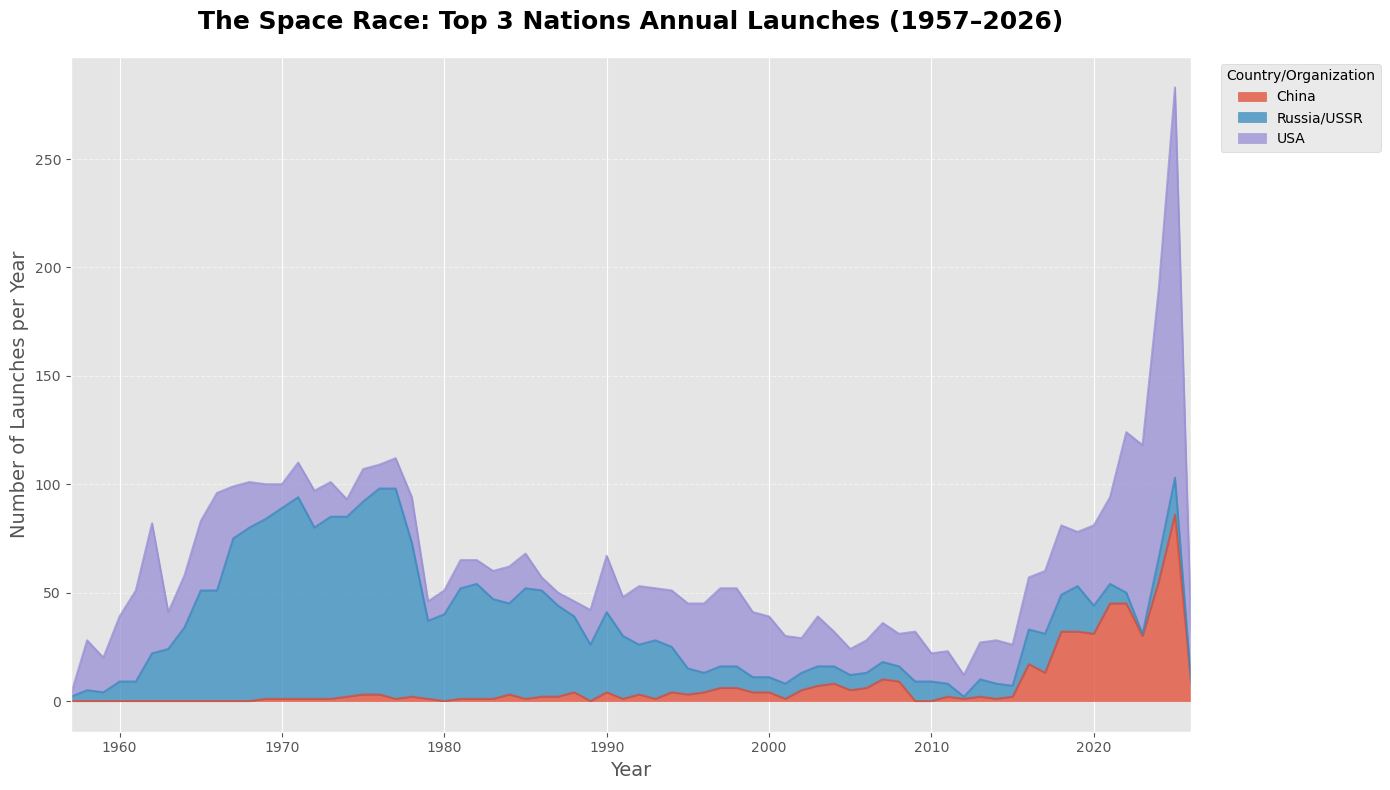

In [1278]:


# 1. Clean and Merge Russia/USSR
space_df['countries'] = space_df['countries'].str.strip()
space_df['countries'] = space_df['countries'].replace({'Kazakhstan': 'Russia/USSR', 'Russia': 'Russia/USSR'})

# 2. Filter years and identify the Top 3 countries
df_filtered = space_df[(space_df['date'] >= 1957) & (space_df['date'] <= 2026)].copy()
top_countries = df_filtered.groupby('countries').size().nlargest(3).index
df_top = df_filtered[df_filtered['countries'].isin(top_countries)]

# 3. Create the Pivot Table for the Top 3
# This organizes the data so each of the 3 countries has its own column
pivot_df = df_top.groupby(['date', 'countries']).size().unstack(fill_value=0)

# 4. Create the Visualization
plt.style.use('ggplot') 
fig, ax = plt.subplots(figsize=(14, 8))

# Create the Stacked Area Plot using the Top 3 data
pivot_df.plot(kind='area', stacked=True, ax=ax, alpha=0.75)

# Formatting
ax.set_title('The Space Race: Top 3 Nations Annual Launches (1957–2026)', fontsize=18, fontweight='bold', pad=20)
ax.set_ylabel('Number of Launches per Year', fontsize=14)
ax.set_xlabel('Year', fontsize=14)
ax.legend(title='Country/Organization', loc='upper left', bbox_to_anchor=(1.02, 1))
ax.set_xlim(pivot_df.index.min(), pivot_df.index.max())
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [1279]:
usa_1970 = space_df[(space_df['date'] == 1970) & (space_df['Location'].str.contains("USA", na=False))]


print(f"Total USA launches in 1970: {len(usa_1970)}")
# print(usa_1970[['Company Name', 'Location', 'Datum', 'Status Mission']])

Total USA launches in 1970: 11


In [1280]:
russia_1970 = space_df[(space_df['date'] == 1970) & (space_df['Location'].str.contains("Russia|Kazakhstan", na=False))]


print(f"Total Russia launches in 1970: {len(russia_1970)}")

Total Russia launches in 1970: 88


In [1285]:
def categorize_provider(company):
    commercial_keywords = [
        'SpaceX', 'Rocket Lab', 'Blue Origin', 'Astra', 'Virgin Orbit', 
        'Firefly', 'i-Space', 'LandSpace', 'Galactic Energy', 'CAS Space',
        'ULA', 'Boeing', 'Northrop Grumman'
    ]
    # Check if any keyword exists in the Company Name string
    if any(keyword.lower() in str(company).lower() for keyword in commercial_keywords):
        return 'Commercial/Private'
    return 'State/Government'

space_df['Provider_Type'] = space_df['Company Name'].apply(categorize_provider)

In [1281]:

# 1. Prepare the data (Reset index so 'Year' is a column for Plotly)
plot_data = pivot_df.reset_index().melt(id_vars='date', var_name='Country', value_name='Launches')

# 2. Create the interactive Area Chart
fig = px.area(plot_data, 
              x="date", 
              y="Launches", 
              color="Country",
              title="The Space Race: Annual Launches (Hover for Details)",
              labels={"Launches": "Number of Launches", "date": "Year"})

# 3. Improve the hover experience
fig.update_layout(
    hovermode="x unified",  # Shows all countries in one box when hovering
    xaxis_title="Year",
    yaxis_title="Total Launches",
    legend_title="Country"
)

fig.show()

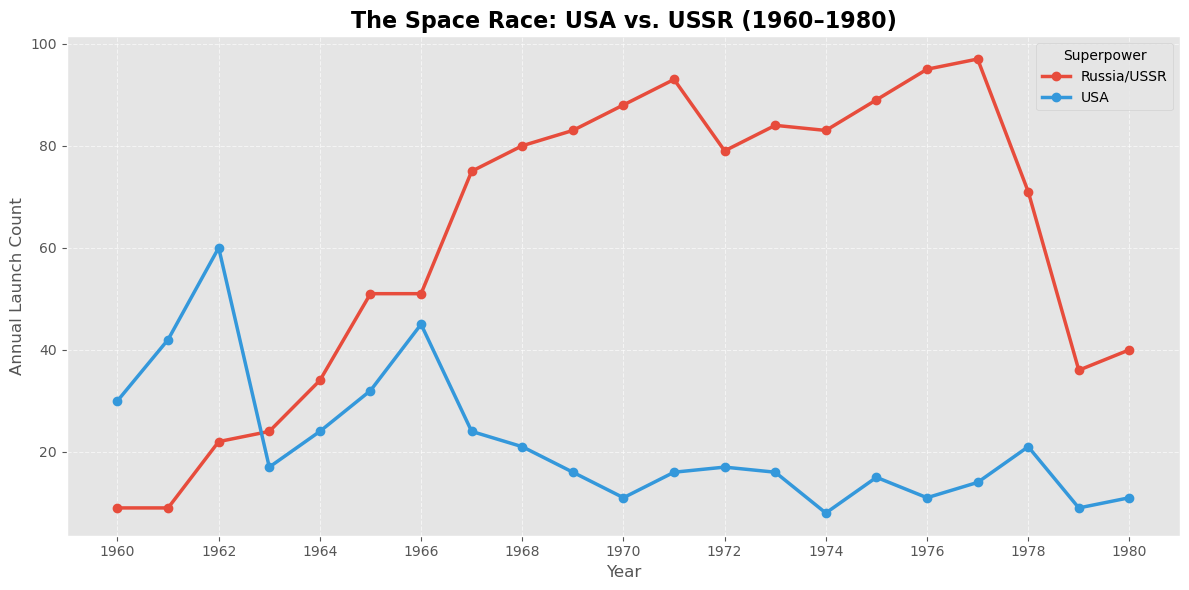

In [1282]:


# 1. Filtering for the specific era (1960-1980) and the two rivals
# Note: Using 'Russia/USSR' to catch all iterations of the Soviet/Russian program
era_df = space_df[(space_df['date'] >= 1960) & (space_df['date'] <= 1980)]
rivals_df = era_df[era_df['countries'].isin(['USA', 'Russia/USSR'])]

# 2. Pivot the data to get annual counts for each
# This creates a table where 'date' is the index and 'USA'/'Russia/USSR' are columns
pivot_rivals = rivals_df.groupby(['date', 'countries']).size().unstack(fill_value=0)

# 3. Create the Visualization
plt.style.use('ggplot')
fig, ax = plt.subplots(figsize=(12, 6))

# Plotting with specific colors (Blue for USA, Red for USSR)
pivot_rivals.plot(kind='line', marker='o', linewidth=2.5, ax=ax, color=['#e74c3c', '#3498db'])

# 4. Formatting for clarity
ax.set_title('The Space Race: USA vs. USSR (1960–1980)', fontsize=16, fontweight='bold')
ax.set_ylabel('Annual Launch Count', fontsize=12)
ax.set_xlabel('Year', fontsize=12)
ax.set_xticks(range(1960, 1981, 2)) # Show every 2 years on the axis
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(title="Superpower")

plt.tight_layout()
plt.show()

In [1283]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Filter for the modern era (1990-2025)
# space_df['date'] = pd.to_numeric(space_df['date'], errors='coerce')
df_modern = space_df[(space_df['date'] >= 1990) & (space_df['date'] <= 2025)].copy()

# 2. Define Grouping Logic
# - Russia/USSR: One unified group
# - USA (State): All US government/military launches
# - USA (Commercial): Individual lines for each company
def categorize_launches(row):
    country = str(row['countries']).strip()
    provider_type = str(row['Provider']).strip() # 'State' or 'Commercial'
    company = str(row['Company Name']).strip()    # e.g., 'SpaceX', 'NASA'
    
    if country in ['Russia', 'Kazakhstan', 'USSR', 'Russia/USSR']:
        return 'Russia/USSR'
    elif country == 'USA':
        if provider_type == 'State':
            return 'USA (State)'
        else:
            return company # Lists individual commercial company name
    return 'Other'

df_modern['Graph_Group'] = df_modern.apply(categorize_launches, axis=1)

# 3. Filter for Russia and USA only
df_plot = df_modern[df_modern['Graph_Group'] != 'Other']

# 4. Prepare data for plotting
pivot_df = df_plot.groupby(['date', 'Graph_Group']).size().unstack(fill_value=0)

# To keep the graph clean, we keep Russia, USA (State), 
# and commercial companies with more than 5 launches in this period.
major_players = pivot_df.sum()[pivot_df.sum() > 5].index
pivot_df = pivot_df[major_players]

# 5. Visualization
plt.style.use('ggplot')
fig, ax = plt.subplots(figsize=(14, 7))

# Plot lines
pivot_df.plot(kind='line', marker='o', ax=ax, linewidth=2, alpha=0.8)

# Formatting
ax.set_title('The Shift to Commercial: Russia vs USA (1990–2025)', fontsize=16, fontweight='bold')
ax.set_ylabel('Annual Launch Count', fontsize=12)
ax.set_xlabel('Year', fontsize=12)
ax.legend(title='Launch Provider', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

KeyError: 'Provider'

In [1284]:
space_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5319 entries, 0 to 5318
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Company Name    5319 non-null   object 
 1   Location        5319 non-null   object 
 2   Datum           5319 non-null   object 
 3   Detail          5318 non-null   object 
 4   Status Rocket   5316 non-null   object 
 5   Price           5319 non-null   float64
 6   Status Mission  5315 non-null   object 
 7   countries       5319 non-null   object 
 8   date            5134 non-null   Int64  
 9   Lat             5008 non-null   float64
 10  Lon             5008 non-null   float64
dtypes: Int64(1), float64(3), object(7)
memory usage: 462.4+ KB


In [ ]:
# Create a simplified 'Type' column
def categorize_provider(company):
    commercial_list = ['SpaceX', 'Rocket Lab', 'Blue Origin', 'Firefly','Firefly Aerospace', 'ULA', 'i-Space', 'Northrop Grumman', 'Virgin Orbit', 'Arianespace','Boeing','Eurockot','ExPace','ILS','Kosmotras','Land Launch', 'lockheed', 'one space', 'sea launch', 'starsem', 'landspace', 'Mitsubishi', 'MHI']

    if company in commercial_list:
        return 'Commercial'
    return 'State'

space_df['Provider'] = space_df['Company Name'].apply(categorize_provider)

# Filter for 2010-2026
# df_modern = space_df[(space_df['date'] >= 1957) & (space_df['date'] <= 2026)]

# # Group and plot to see the transition
# pivot_modern = df_modern.groupby(['date', 'Provider']).size().unstack(fill_value=0)
# pivot_modern.plot(kind='area', stacked=True, alpha=0.7)

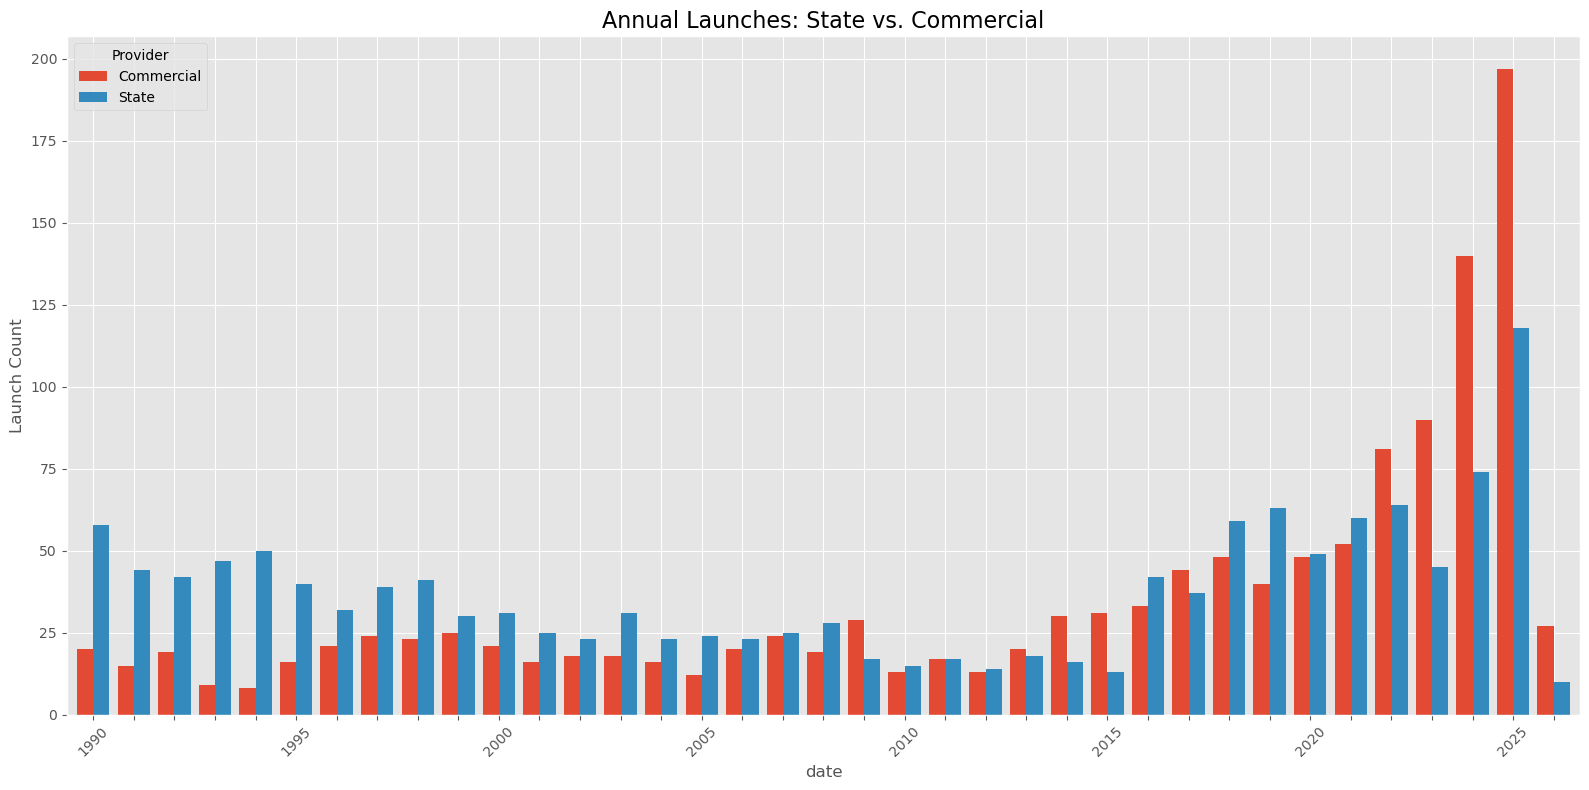

In [ ]:
import matplotlib.pyplot as plt


# 1. Filter for the date range
df_modern = space_df[(space_df['date'] >= 1990) & (space_df['date'] <= 2026)].copy()

# 2. Pivot using the existing 'Provider' column
# This creates a table where 'date' is the row and 'State'/'Commercial' are the columns
pivot_sector = df_modern.groupby(['date', 'Provider']).size().unstack(fill_value=0)

# 3. Create the bar chart
fig, ax = plt.subplots(figsize=(16, 8))

# stacked=False puts the State and Commercial bars side-by-side
pivot_sector.plot(kind='bar', stacked=False, ax=ax, width=0.8)

# 4. Clean up the labels so they don't overlap
for i, label in enumerate(ax.get_xticklabels()):
    if i % 5 != 0:
        label.set_visible(False)

# Formatting
ax.set_title('Annual Launches: State vs. Commercial', fontsize=16)
ax.set_ylabel('Launch Count')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

<Axes: xlabel='date'>

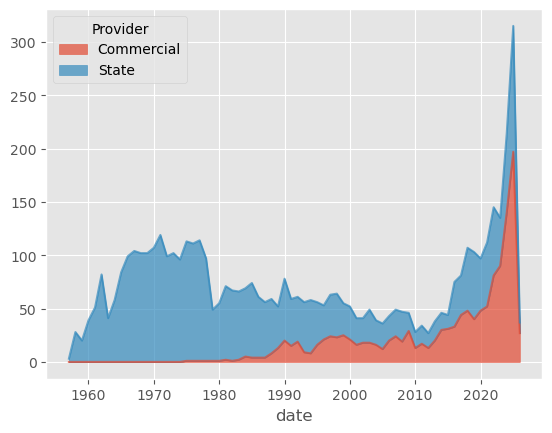

In [ ]:
df_modern = space_df[(space_df['date'] >= 1957) & (space_df['date'] <= 2026)]

# Group and plot to see the transition
pivot_modern = df_modern.groupby(['date', 'Provider']).size().unstack(fill_value=0)
pivot_modern.plot(kind='area', stacked=True, alpha=0.7)

In [ ]:
unique_companies = space_df['Company Name'].unique()
print(unique_companies)

['SpaceX' 'CASC' 'Arianespace' 'ULA' 'Rocket Lab' 'Blue Origin'
 'Galactic Energy' 'ISRO' 'VKS' 'Roscosmos' 'AST SpaceMobile' 'JAXA' 'ESA'
 'Firefly' 'ExPace' 'LandSpace' 'SIAS' 'KARI' 'ISA' 'Firefly Aerospace'
 'Northrop Grumman' 'Isar Aerospace' 'CAS Space' 'Orienspace' 'i-Space'
 'CGSTL' 'NADA' 'Space One' 'China Rocket' 'IRGC' 'MHI' 'Amazon/ULA'
 'Relativity Space' 'ABL Space' 'Virgin Orbit' 'NASA' 'Astra' 'NASA/ESA'
 'Northrop' 'IAI' 'VKS RF' 'Exos' 'ILS' 'OneSpace' 'Landspace' 'Eurockot'
 'Land Launch' 'CASIC' 'KCST' 'Sandia' 'Kosmotras' 'Khrunichev'
 'Sea Launch' 'Boeing' 'ISAS' 'SRC' 'MITT' 'Lockheed' 'AEB' 'Starsem' 'ed'
 'RVSN USSR' 'EER' 'General Dynamics' 'Martin Marietta' 'Yuzhmash'
 'Douglas' 'smodrome' 'ASI' 'US Air Force' 'CNES' 'z U | Cosmos 670'
 'CECLES' 'RAE' 'UT' 'OKB-586' 'AMBA' "Arm??e de l'Air" 'US Navy']


In [ ]:
space_df.sample()

,Company Name,Location,Datum,Detail,Status Rocket,Price,Status Mission,countries,date,Lat,Lon,Provider
215,JAXA,"Tanegashima, Japan",Jun 28 2025 05:00 UTC,H-IIA 202 | GOSAT-GW (Final H-IIA),StatusRetired,90.0,Success,Japan,2025,30.4018,130.9774,State


In [ ]:
company_audit = space_df[['Company Name', 'Provider']].drop_duplicates().sort_values(by=['Provider', 'Company Name'])

# Display the classification for you to check
print("--- Company Classification Audit ---")
with pd.option_context('display.max_rows', None): # Shows the full list
    print(company_audit)

# Show the balance of the dataset
print("\n--- Total Unique Companies per Category ---")
print(company_audit['Provider'].value_counts(50))

--- Company Classification Audit ---
           Company Name    Provider
9           Arianespace  Commercial
20          Blue Origin  Commercial
1887             Boeing  Commercial
1243           Eurockot  Commercial
60               ExPace  Commercial
55              Firefly  Commercial
258   Firefly Aerospace  Commercial
1088                ILS  Commercial
1504          Kosmotras  Commercial
1282        Land Launch  Commercial
553                 MHI  Commercial
272    Northrop Grumman  Commercial
16           Rocket Lab  Commercial
0                SpaceX  Commercial
10                  ULA  Commercial
694        Virgin Orbit  Commercial
434             i-Space  Commercial
692           ABL Space       State
2025                AEB       State
4706               AMBA       State
2946                ASI       State
44      AST SpaceMobile       State
595          Amazon/ULA       State
4795    Arm??e de l'Air       State
782               Astra       State
369           CAS Space    